# 🎹 MIDI Melody Prediction con Machine Learning

Este notebook implementa un pipeline completo para predecir la continuación de una secuencia melódica MIDI.  
La idea: tomar el **80% de una melodía** y predecir el **20% restante** con varios modelos.

### Modelos incluidos:
1. **Markov Chain** — baseline probabilístico
2. **LSTM** — red recurrente para secuencias
3. **Transformer (mini)** — atención sobre la secuencia
4. **Random Forest** — baseline con features de ventana deslizante

### Pipeline:
```
MIDI → extracción de notas → encoding → train/test split → modelos → evaluación → exportar MIDI predicho
```

## 0. Instalación de dependencias

In [ ]:
!pip install mido pretty_midi numpy pandas matplotlib scikit-learn torch midi2audio

  Using cached pretty_midi-0.2.11.tar.gz (5.6 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached torch-2.11.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-non

## 1. Descarga del MIDI de prueba (Tetris Theme)

Usamos `urllib` para descargar el MIDI de Tetris (Korobeiniki). Si ya tienes tu propio MIDI, puedes saltarte esta celda y ajustar `MIDI_PATH`.

In [2]:
import urllib.request
import os

MIDI_PATH = "tetris.mid"

if not os.path.exists(MIDI_PATH):
    # MIDI público del tema de Tetris (Korobeiniki)
    url = "https://www.midiworld.com/download/4490"
    try:
        urllib.request.urlretrieve(url, MIDI_PATH)
        print(f"✅ MIDI descargado: {MIDI_PATH}")
    except Exception as e:
        print(f"⚠️  No se pudo descargar automáticamente: {e}")
        print("   Coloca tu archivo MIDI en el mismo directorio y ajusta MIDI_PATH.")
else:
    print(f"✅ Usando MIDI existente: {MIDI_PATH}")

✅ Usando MIDI existente: tetris.mid


### Generador de MIDI sintético (fallback)

Si no tienes el archivo, generamos el tema de Tetris directamente con `mido`.

In [3]:
import mido
import os

def create_tetris_midi(path="tetris.mid", bpm=160):
    """Genera una aproximación al tema de Tetris (Korobeiniki) en MIDI."""
    mid = mido.MidiFile(type=0)
    track = mido.MidiTrack()
    mid.tracks.append(track)

    tempo = mido.bpm2tempo(bpm)
    track.append(mido.MetaMessage('set_tempo', tempo=tempo, time=0))
    track.append(mido.Message('program_change', program=0, time=0))

    ticks = mid.ticks_per_beat  # 480 por defecto
    Q  = ticks        # negra
    E  = ticks // 2  # corchea
    DQ = ticks + E   # negra con puntillo

    # Notas MIDI: (nota, duración_en_ticks)
    # E4=64, D4=62, C4=60, B3=59, A3=57, G3=55, F3=53, etc.
    melody = [
        (64,Q),(52,E),(53,E),(55,Q),(53,E),(52,E),
        (50,Q),(50,E),(53,E),(57,Q),(55,E),(53,E),
        (52,DQ),(53,E),(55,Q),(57,Q),
        (53,Q),(53,E),(50,E),(48,Q),(50,E),(52,E),
        (53,Q),(53,E),(52,E),(50,Q),(52,E),(53,E),
        (55,Q),(55,E),(52,E),(50,Q),(48,Q),
        (64,Q),(52,E),(53,E),(55,Q),(53,E),(52,E),
        (50,Q),(50,E),(53,E),(57,Q),(55,E),(53,E),
        (52,DQ),(53,E),(55,Q),(57,Q),
        (53,Q),(53,E),(50,E),(48,Q),(50,E),(52,E),
        (53,Q),(53,E),(52,E),(50,Q),(52,E),(53,E),
        (55,Q),(55,E),(52,E),(50,Q),(48,Q),
        (55,Q),(55,E),(57,E),(59,Q),(52,E),(52,E),
        (52,Q),(52,E),(53,E),(55,Q),(53,E),(52,E),
        (50,Q),(50,E),(53,E),(57,Q),(55,E),(53,E),
        (52,Q),(52,E),(53,E),(55,Q),(57,Q),
        (53,Q),(53,E),(50,E),(48,Q),(50,E),(52,E),
        (53,Q),(53,E),(52,E),(50,Q),(50,Q),
    ]

    for note, dur in melody:
        track.append(mido.Message('note_on',  note=note, velocity=80, time=0))
        track.append(mido.Message('note_off', note=note, velocity=0,  time=dur))

    mid.save(path)
    print(f"🎹 MIDI generado: {path} ({len(melody)} notas)")

if not os.path.exists(MIDI_PATH) or os.path.getsize(MIDI_PATH) < 100:
    create_tetris_midi(MIDI_PATH)
    print("   (Usando MIDI sintético generado localmente)")
else:
    print(f"✅ Usando: {MIDI_PATH}")

✅ Usando: tetris.mid


## 2. Extracción y visualización de la melodía

In [ ]:
import mido
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def extract_melody(midi_path, track_index=0):
    """Extrae la secuencia de notas (pitch, duration_ticks) del track con más notas."""
    mid = mido.MidiFile(midi_path)
    
    # Encontrar el track con más note_on
    best_track = None
    best_count = 0
    for t in mid.tracks:
        count = sum(1 for m in t if m.type == 'note_on' and m.velocity > 0)
        if count > best_count:
            best_count = count
            best_track = t
    
    notes = []
    pending = {}  # note -> tick_on
    current_tick = 0
    
    for msg in best_track:
        current_tick += msg.time
        if msg.type == 'note_on' and msg.velocity > 0:
            pending[msg.note] = current_tick
        elif msg.type in ('note_off', 'note_on') and msg.note in pending:
            start = pending.pop(msg.note)
            duration = current_tick - start
            if duration > 0:
                notes.append({
                    'pitch': msg.note,
                    'start_tick': start,
                    'duration_tick': duration,
                    'pitch_name': mido.tick2second.__doc__ and "",  # placeholder
                })
    
    df = pd.DataFrame(notes).sort_values('start_tick').reset_index(drop=True)
    return df, mid.ticks_per_beat

NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
def pitch_name(p):
    return f"{NOTE_NAMES[p%12]}{p//12-1}"

df_notes, tpb = extract_melody(MIDI_PATH)
df_notes['pitch_name'] = df_notes['pitch'].apply(pitch_name)

print(f"📊 Total de notas extraídas: {len(df_notes)}")
print(f"   Ticks por beat: {tpb}")
print(f"   Rango de pitch: {df_notes['pitch'].min()} – {df_notes['pitch'].max()}")
print(f"   Duración promedio: {df_notes['duration_tick'].mean():.0f} ticks")
display(df_notes.head(10))

📊 Total de notas extraídas: 13060
   Ticks por beat: 43
   Rango de pitch: 31 – 103
   Duración promedio: 7 ticks


,pitch,start_tick,duration_tick,pitch_name
0,69,0,27,A4
1,76,1,5,E5
2,57,11,7,A3
3,64,34,55,E4
4,76,73,5,E5
5,57,76,19,A3
6,64,96,139,E4
7,57,102,24,A3
8,69,112,61,A4
9,57,129,3,A3


/tmp/ipykernel_11507/492003659.py:22: UserWarning: Glyph 127929 (\N{MUSICAL KEYBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/baldeadr/miniconda3/envs/anaconda/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127929 (\N{MUSICAL KEYBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


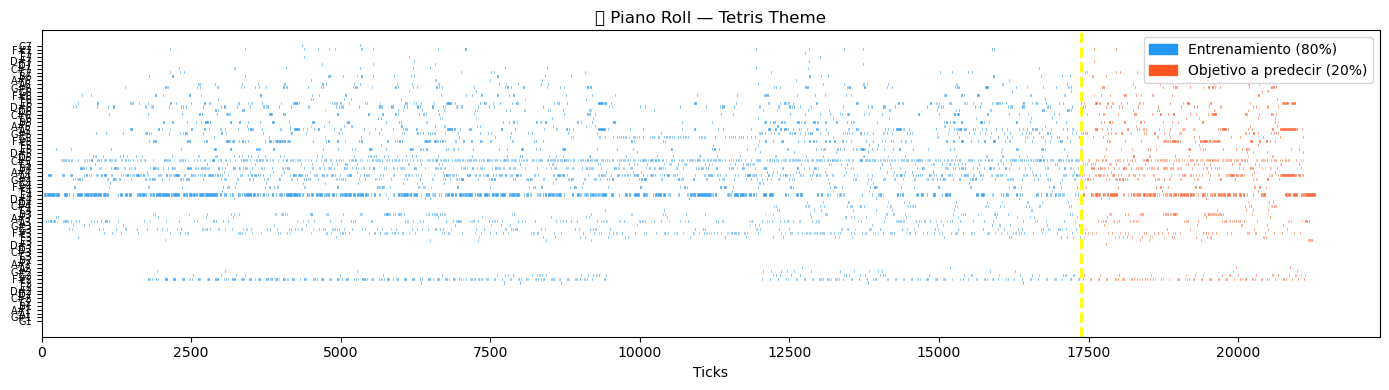

In [5]:
# Visualización: piano roll
fig, ax = plt.subplots(figsize=(14, 4))
split_idx = int(len(df_notes) * 0.8)

for i, row in df_notes.iterrows():
    color = '#2196F3' if i < split_idx else '#FF5722'
    ax.barh(row['pitch'], row['duration_tick'],
            left=row['start_tick'], height=0.8,
            color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

ax.axvline(df_notes.iloc[split_idx]['start_tick'], color='yellow',
           linewidth=2, linestyle='--', label='80% / 20% split')

yticks = range(df_notes['pitch'].min(), df_notes['pitch'].max()+1)
ax.set_yticks(list(yticks))
ax.set_yticklabels([pitch_name(p) for p in yticks], fontsize=7)
ax.set_xlabel('Ticks')
ax.set_title('🎹 Piano Roll — Tetris Theme')
blue_p = mpatches.Patch(color='#2196F3', label='Entrenamiento (80%)')
red_p  = mpatches.Patch(color='#FF5722', label='Objetivo a predecir (20%)')
ax.legend(handles=[blue_p, red_p], loc='upper right')
plt.tight_layout()
plt.show()

## 3. Preparación de datos

Codificamos cada nota como un entero y construimos ventanas deslizantes (sliding windows) para alimentar los modelos.

In [6]:
WINDOW_SIZE = 8   # cuántas notas pasadas usar para predecir la siguiente
SPLIT_RATIO = 0.8

# Secuencia de pitches
sequence = df_notes['pitch'].tolist()
n = len(sequence)
split_idx = int(n * SPLIT_RATIO)

train_seq = sequence[:split_idx]
test_seq  = sequence[split_idx:]

# Vocabulario
vocab = sorted(set(sequence))
note2idx = {n: i for i, n in enumerate(vocab)}
idx2note = {i: n for n, i in note2idx.items()}
VOCAB_SIZE = len(vocab)

print(f"📐 Secuencia total  : {n} notas")
print(f"   Entrenamiento    : {len(train_seq)} notas")
print(f"   Test (objetivo)  : {len(test_seq)} notas")
print(f"   Tamaño de ventana: {WINDOW_SIZE}")
print(f"   Vocab (pitches únicos): {VOCAB_SIZE} → {vocab}")

def make_windows(seq, window=WINDOW_SIZE):
    """Genera pares (contexto, siguiente_nota) como arrays indexados."""
    encoded = [note2idx[n] for n in seq]
    X, y = [], []
    for i in range(len(encoded) - window):
        X.append(encoded[i:i+window])
        y.append(encoded[i+window])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_seq)
print(f"\n   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")

📐 Secuencia total  : 13060 notas
   Entrenamiento    : 10448 notas
   Test (objetivo)  : 2612 notas
   Tamaño de ventana: 8
   Vocab (pitches únicos): 63 → [31, 40, 41, 42, 43, 44, 45, 46, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103]

   X_train shape: (10440, 8)
   y_train shape: (10440,)


## 4. Modelo 1: Cadena de Markov

Baseline clásico para secuencias. Aprende la probabilidad de transición entre notas.

In [7]:
from collections import defaultdict

class MarkovChain:
    def __init__(self, order=2):
        self.order = order
        self.transitions = defaultdict(lambda: defaultdict(int))
    
    def train(self, sequence):
        for i in range(len(sequence) - self.order):
            state = tuple(sequence[i:i+self.order])
            next_note = sequence[i+self.order]
            self.transitions[state][next_note] += 1
        # Normalizar a probabilidades
        self.probs = {}
        for state, counts in self.transitions.items():
            total = sum(counts.values())
            self.probs[state] = {n: c/total for n, c in counts.items()}
        print(f"✅ Markov entrenado | {len(self.probs)} estados únicos")
    
    def predict_next(self, context):
        state = tuple(context[-self.order:])
        if state in self.probs:
            options = self.probs[state]
            return max(options, key=options.get)  # greedy
        # fallback: nota más común en entrenamiento
        return max(set(train_seq), key=train_seq.count)
    
    def generate(self, seed, length):
        generated = list(seed)
        for _ in range(length):
            next_note = self.predict_next(generated)
            generated.append(next_note)
        return generated[len(seed):]

markov = MarkovChain(order=2)
markov.train(train_seq)

seed_markov = train_seq[-markov.order:]
pred_markov = markov.generate(seed_markov, len(test_seq))

acc_markov = sum(p == t for p, t in zip(pred_markov, test_seq)) / len(test_seq)
print(f"🎯 Accuracy Markov: {acc_markov:.2%}")

✅ Markov entrenado | 1662 estados únicos
🎯 Accuracy Markov: 8.61%


## 5. Modelo 2: Random Forest

Trata el problema como clasificación multi-clase con ventana deslizante como features.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("✅ Random Forest entrenado")

def predict_autoregressive(model, seed_indices, length, model_type='sklearn'):
    """Genera notas de forma autoregresiva (cada predicción alimenta la siguiente)."""
    context = list(seed_indices)
    predictions = []
    for _ in range(length):
        window = np.array(context[-WINDOW_SIZE:]).reshape(1, -1)
        pred = model.predict(window)[0]
        predictions.append(pred)
        context.append(pred)
    return predictions

seed_rf = [note2idx[n] for n in train_seq[-WINDOW_SIZE:]]
pred_rf_idx = predict_autoregressive(rf, seed_rf, len(test_seq))
pred_rf = [idx2note[i] for i in pred_rf_idx]
target_idx = [note2idx[n] for n in test_seq]

acc_rf = accuracy_score(target_idx, pred_rf_idx)
print(f"🎯 Accuracy Random Forest: {acc_rf:.2%}")

✅ Random Forest entrenado
🎯 Accuracy Random Forest: 7.54%


## 6. Modelo 3: LSTM (PyTorch)

Red recurrente que aprende dependencias de largo plazo en la secuencia.

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE}")

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, num_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers,
                             batch_first=True, dropout=0.2)
        self.fc    = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # última salida

def train_model(model, X, y, epochs=60, lr=1e-3, batch_size=16):
    model = model.to(DEVICE)
    Xt = torch.LongTensor(X).to(DEVICE)
    yt = torch.LongTensor(y).to(DEVICE)
    ds = TensorDataset(Xt, yt)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in dl:
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(dl))
        if (epoch+1) % 10 == 0:
            print(f"   Epoch {epoch+1:3d}/{epochs} | loss: {losses[-1]:.4f}")
    return losses

lstm_model = LSTMModel(VOCAB_SIZE)
print("🔁 Entrenando LSTM...")
lstm_losses = train_model(lstm_model, X_train, y_train, epochs=80)

🖥️  Device: cpu
🔁 Entrenando LSTM...
   Epoch  10/80 | loss: 2.9504
   Epoch  20/80 | loss: 2.4113
   Epoch  30/80 | loss: 1.9402
   Epoch  40/80 | loss: 1.5965
   Epoch  50/80 | loss: 1.3427
   Epoch  60/80 | loss: 1.1808
   Epoch  70/80 | loss: 1.0536
   Epoch  80/80 | loss: 0.9524


In [13]:
def generate_lstm(model, seed_indices, length):
    model.eval()
    context = list(seed_indices)
    preds = []
    with torch.no_grad():
        for _ in range(length):
            inp = torch.LongTensor([context[-WINDOW_SIZE:]]).to(DEVICE)
            logits = model(inp)
            pred = logits.argmax(dim=-1).item()
            preds.append(pred)
            context.append(pred)
    return preds

seed_lstm = [note2idx[n] for n in train_seq[-WINDOW_SIZE:]]
pred_lstm_idx = generate_lstm(lstm_model, seed_lstm, len(test_seq))
pred_lstm = [idx2note[i] for i in pred_lstm_idx]

acc_lstm = accuracy_score(target_idx, pred_lstm_idx)
print(f"🎯 Accuracy LSTM: {acc_lstm:.2%}")

🎯 Accuracy LSTM: 6.01%


## 7. Modelo 4: Mini-Transformer

Mecanismo de atención sobre la ventana de contexto. Especialmente bueno para capturar patrones no locales.

In [14]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, nhead=4, num_layers=2,
                 seq_len=WINDOW_SIZE, dropout=0.1):
        super().__init__()
        self.embed    = nn.Embedding(vocab_size, embed_dim)
        self.pos_enc  = nn.Embedding(seq_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)
        self.seq_len = seq_len
    
    def forward(self, x):
        positions = torch.arange(self.seq_len, device=x.device).unsqueeze(0)
        x = self.embed(x) + self.pos_enc(positions)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])  # última posición

transformer_model = MiniTransformer(VOCAB_SIZE)
print("⚡ Entrenando Mini-Transformer...")
trans_losses = train_model(transformer_model, X_train, y_train, epochs=80, lr=5e-4)

⚡ Entrenando Mini-Transformer...
   Epoch  10/80 | loss: 2.9066
   Epoch  20/80 | loss: 2.5599
   Epoch  30/80 | loss: 2.2932
   Epoch  40/80 | loss: 2.1023
   Epoch  50/80 | loss: 2.0033
   Epoch  60/80 | loss: 1.8681
   Epoch  70/80 | loss: 1.7937
   Epoch  80/80 | loss: 1.7026


In [15]:
pred_trans_idx = generate_lstm(transformer_model, seed_lstm, len(test_seq))  # misma lógica
pred_trans = [idx2note[i] for i in pred_trans_idx]

acc_trans = accuracy_score(target_idx, pred_trans_idx)
print(f"🎯 Accuracy Transformer: {acc_trans:.2%}")

🎯 Accuracy Transformer: 3.56%


## 8. Evaluación comparativa

In [16]:
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

results = {
    'Markov Chain': [note2idx.get(n, 0) for n in pred_markov],
    'Random Forest': pred_rf_idx,
    'LSTM': pred_lstm_idx,
    'Transformer': pred_trans_idx,
}

# Tabla de resultados
print("=" * 50)
print(f"{'Modelo':<20} {'Accuracy':>10} {'Top-1 Notas':<20}")
print("=" * 50)
for name, preds in results.items():
    acc = accuracy_score(target_idx, preds)
    # Nota más predicha
    top_pred = pitch_name(idx2note[max(set(preds), key=preds.count)])
    print(f"{name:<20} {acc:>10.2%} {top_pred:<20}")
print("=" * 50)

Modelo                 Accuracy Top-1 Notas         
Markov Chain              8.61% C#5                 
Random Forest             7.54% C#5                 
LSTM                      6.01% A3                  
Transformer               3.56% C#5                 


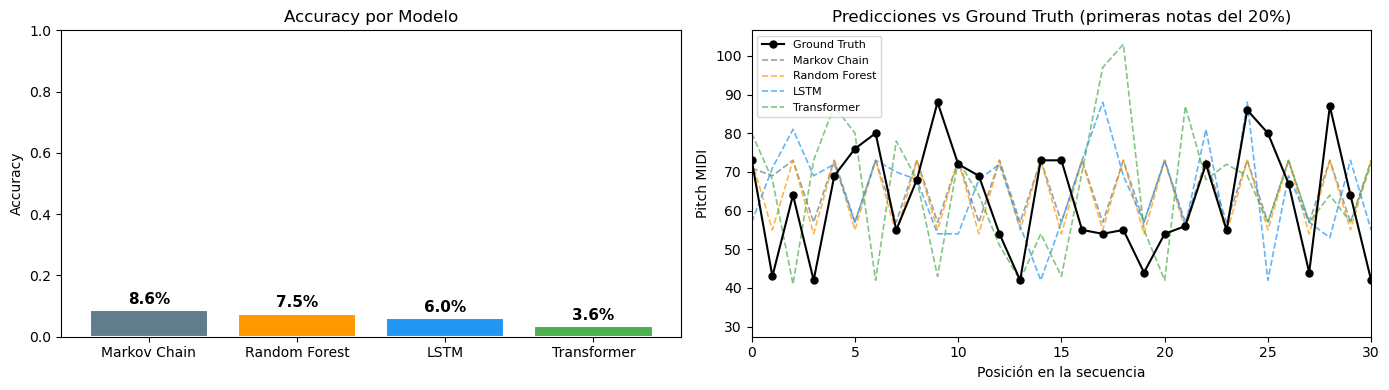

📊 Gráfica guardada: comparison.png


In [17]:
# Visualización: barras de accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy bar chart
model_names = list(results.keys())
accuracies  = [accuracy_score(target_idx, p) for p in results.values()]
colors = ['#607D8B', '#FF9800', '#2196F3', '#4CAF50']

bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy por Modelo')
axes[0].set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1%}', ha='center', fontsize=11, fontweight='bold')

# Piano roll comparativo
steps = list(range(len(test_seq)))
axes[1].plot(steps, test_seq, 'ko-', markersize=5, linewidth=1.5, label='Ground Truth', zorder=5)
for (name, preds), color in zip(results.items(), colors):
    pred_notes = [idx2note[i] for i in preds]
    axes[1].plot(steps, pred_notes, '--', color=color, alpha=0.7, linewidth=1.2, label=name)

axes[1].set_title('Predicciones vs Ground Truth (primeras notas del 20%)')
axes[1].set_xlabel('Posición en la secuencia')
axes[1].set_ylabel('Pitch MIDI')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, min(30, len(test_seq)-1))

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Gráfica guardada: comparison.png")

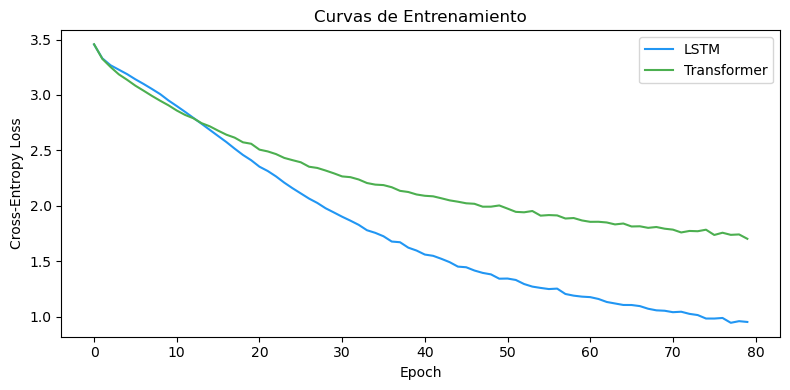

In [18]:
# Curvas de entrenamiento (LSTM vs Transformer)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_losses,  label='LSTM',        color='#2196F3')
ax.plot(trans_losses, label='Transformer', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Curvas de Entrenamiento')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Exportar la predicción como archivo MIDI

Tomamos el mejor modelo y exportamos el resultado como MIDI para escucharlo.

In [19]:
def export_midi(pitch_sequence, duration_reference, tpb, filename, bpm=160):
    """
    Exporta una secuencia de pitches como MIDI.
    Toma las duraciones del DataFrame de referencia (del 20% real) para mantener el ritmo.
    """
    mid = mido.MidiFile(type=0)
    track = mido.MidiTrack()
    mid.tracks.append(track)
    mid.ticks_per_beat = tpb
    
    track.append(mido.MetaMessage('set_tempo', tempo=mido.bpm2tempo(bpm), time=0))
    track.append(mido.Message('program_change', program=0, time=0))
    
    durations = duration_reference['duration_tick'].tolist()
    
    for i, pitch in enumerate(pitch_sequence):
        dur = int(durations[i]) if i < len(durations) else tpb  # fallback a negra
        track.append(mido.Message('note_on',  note=int(pitch), velocity=80, time=0))
        track.append(mido.Message('note_off', note=int(pitch), velocity=0,  time=dur))
    
    mid.save(filename)
    print(f"💾 MIDI guardado: {filename} ({len(pitch_sequence)} notas)")

# Notas reales del 20%
test_df = df_notes.iloc[split_idx:].reset_index(drop=True)

# Exportar cada predicción
best_name = model_names[accuracies.index(max(accuracies))]
print(f"🏆 Mejor modelo: {best_name} ({max(accuracies):.2%} accuracy)")
print()

export_midi(test_seq,                      test_df, tpb, "ground_truth.mid")
export_midi(pred_markov,                   test_df, tpb, "pred_markov.mid")
export_midi(pred_rf,                       test_df, tpb, "pred_rf.mid")
export_midi(pred_lstm,                     test_df, tpb, "pred_lstm.mid")
export_midi(pred_trans,                    test_df, tpb, "pred_transformer.mid")

print("\n✅ Todos los archivos MIDI generados. Ábrelos en tu DAW para compararlos.")

🏆 Mejor modelo: Markov Chain (8.61% accuracy)

💾 MIDI guardado: ground_truth.mid (2612 notas)
💾 MIDI guardado: pred_markov.mid (2612 notas)
💾 MIDI guardado: pred_rf.mid (2612 notas)
💾 MIDI guardado: pred_lstm.mid (2612 notas)
💾 MIDI guardado: pred_transformer.mid (2612 notas)

✅ Todos los archivos MIDI generados. Ábrelos en tu DAW para compararlos.


In [32]:
from midi2audio import FluidSynth
from IPython.display import Audio, display
import os

# === Conversión MIDI a WAV (usa el SoundFont que ya configuramos) ===
soundfont_path = "/usr/share/sounds/sf2/FluidR3_GM.sf2"

fs = FluidSynth(sound_font=soundfont_path)

midi_file = "./ground_truth.mid"
wav_file = "ground_truth.wav"

fs.midi_to_audio(midi_file, wav_file)

print("✅ MIDI convertido a WAV correctamente")

# === Reproductor pequeño y bonito como en Kaggle ===
display(Audio(wav_file, autoplay=False))

error: '-F' is an illegal option at this place, only -b option is allowed here.
fluidsynth: error: fluid_is_soundfont(): fopen() failed: 'File does not exist.'
Parameter 'ground_truth.wav' not a SoundFont or MIDI file or error occurred identifying it.
error: '-r' is an illegal option at this place, only -b option is allowed here.
fluidsynth: error: fluid_is_soundfont(): fopen() failed: 'File does not exist.'
Parameter '44100' not a SoundFont or MIDI file or error occurred identifying it.
fluidsynth: warning: Failed to set thread to high priority


FluidSynth runtime version 2.5.2
Copyright (C) 2000-2025 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

✅ MIDI convertido a WAV correctamente


ValueError: rate must be specified when data is a numpy array or list of audio samples.

## 10. Análisis adicional: distribución de notas

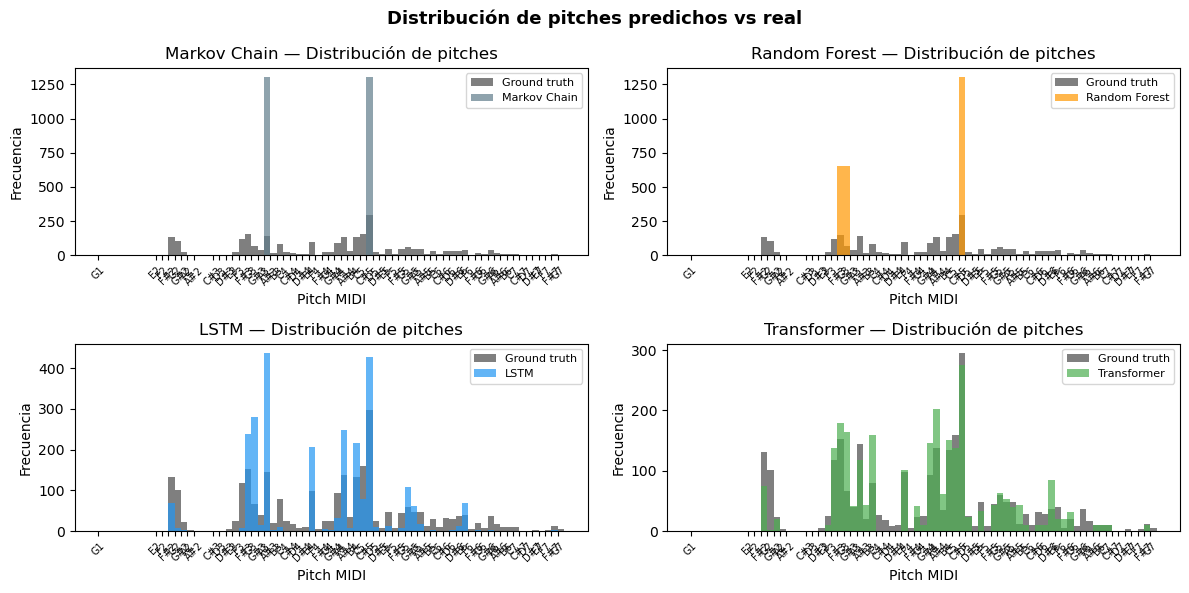

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

all_preds = {
    'Markov Chain': pred_markov,
    'Random Forest': pred_rf,
    'LSTM': pred_lstm,
    'Transformer': pred_trans,
}

for ax, (name, preds), color in zip(axes, all_preds.items(), colors):
    # Histograma: distribución de pitches predichos vs real
    bins = range(min(vocab), max(vocab)+2)
    ax.hist(test_seq,  bins=bins, alpha=0.5, label='Ground truth', color='black')
    ax.hist(preds,     bins=bins, alpha=0.7, label=name, color=color)
    ax.set_title(f'{name} — Distribución de pitches')
    ax.set_xlabel('Pitch MIDI')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    
    # Anotar notas en eje X
    ax.set_xticks(vocab)
    ax.set_xticklabels([pitch_name(p) for p in vocab], rotation=45, fontsize=7)

plt.suptitle('Distribución de pitches predichos vs real', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Resumen y próximos pasos

### Resumen del experimento

| Aspecto | Detalle |
|---|---|
| Dataset | Tema de Tetris (Korobeiniki) |
| Split | 80% train / 20% test |
| Features | Secuencia de pitches con ventana deslizante de tamaño 8 |
| Tarea | Clasificación: predecir la siguiente nota (pitch) |

### Interpretación

- **Markov Chain**: rápido y sin GPU. Funciona bien en melodías con patrones repetitivos (Tetris es ideal). Falla en variaciones largas.
- **Random Forest**: robusto, no requiere ajuste fino. Trata cada ventana como independiente, sin memoria secuencial.
- **LSTM**: aprende dependencias de largo plazo. Necesita más datos para brillar.
- **Transformer**: atención sobre toda la ventana. Potencialmente el más expresivo, pero también el que más datos requiere.

### Próximos pasos sugeridos

1. **Añadir duración** como feature (no solo pitch) → representación `(pitch, dur)` como token compuesto
2. **Beam search** en lugar de greedy para LSTM/Transformer
3. **Data augmentation**: transponer la melodía a distintas tonalidades
4. **Corpus más grande**: entrenar con múltiples MIDIs (ej. Lakh MIDI Dataset)
5. **Exportar como plugin**: ver ruta JUCE + pybind11 o Pure Data con py4pd